# 🚢 Titanic - Machine Learning from Disaster

## Phase 2: Data Quality Audit & Cleaning

### Objective

The objective of this notebook is to systematically audit the quality of the raw Titanic data and identify issues that could affect exploratory analysis, feature engineering, and machine learning.

In this phase, we will:

* Reload the original raw datasets.
* Verify dataset integrity and structure.
* Identify missing values and quantify their severity.
* Check for duplicate records and identifier problems.
* Validate categorical values.
* Inspect numerical features for impossible or suspicious values.
* Investigate missing-value patterns where appropriate.
* Compare data quality between the training and test datasets.
* Decide which issues should be corrected immediately and which should be deferred to feature engineering or model preprocessing.
* Create an initial cleaned version of the data without destroying potentially useful information.
* Validate the cleaned datasets before saving them.

## 1. Import Libraries

We begin by importing the libraries required for data manipulation, numerical analysis, and basic data-quality visualization.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Raw Datasets

The training and test datasets are loaded directly from the `data/raw/` directory.

In [41]:
train = pd.read_csv("/mnt/d/Acelin/Work/Code/titanic-kaggle/data/raw/train.csv")
test = pd.read_csv("/mnt/d/Acelin/Work/Code/titanic-kaggle/data/raw/test.csv")

print("Raw datasets loaded successfully.")

print(f"Training shape: {train.shape}")
print(f"Test shape: {test.shape}")

Raw datasets loaded successfully.
Training shape: (891, 12)
Test shape: (418, 11)


## 3. Create Working Copies

Before applying any cleaning operations, we create copies of the raw DataFrames.

This provides a clear distinction between:

* `train` and `test` — untouched raw data loaded from disk.
* `train_clean` and `test_clean` — working copies on which cleaning operations may be performed.

In [5]:
train_clean = train.copy()
test_clean = test.copy()

print("Working copies created.")

print(f"Raw training shape:     {train.shape}")
print(f"Working training shape: {train_clean.shape}")

print(f"\nRaw test shape:         {test.shape}")
print(f"Working test shape:     {test_clean.shape}")

Working copies created.
Raw training shape:     (891, 12)
Working training shape: (891, 12)

Raw test shape:         (418, 11)
Working test shape:     (418, 11)


## 4. Structural Integrity Check

Before cleaning individual features, we verify that the overall structure of the datasets is consistent with our expectations.

We will check:

* Dataset dimensions.
* Column names.
* Whether the training dataset contains the target variable.
* Whether the test dataset excludes the target variable.
* Whether the remaining predictor columns are consistent between train and test.

In [6]:
print("Training columns:")
print(train_clean.columns.tolist())

print("\nTest columns:")
print(test_clean.columns.tolist())

print("\nColumns only in training data:")
print(set(train_clean.columns) - set(test_clean.columns))

print("\nColumns only in test data:")
print(set(test_clean.columns) - set(train_clean.columns))

Training columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Test columns:
['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Columns only in training data:
{'Survived'}

Columns only in test data:
set()


## 5. Missing Value Audit

Missing values are one of the primary data-quality concerns in the Titanic dataset.

For each feature, we will calculate:

* The number of missing values.
* The percentage of observations that are missing.

In [7]:
def missing_summary(df):
    summary = pd.DataFrame({
        "Data Type": df.dtypes.astype(str),
        "Missing Count": df.isnull().sum(),
        "Missing Percentage": (df.isnull().mean() * 100).round(2)
    })

    summary = summary[
        summary["Missing Count"] > 0
    ].sort_values(
        by="Missing Percentage",
        ascending=False
    )

    return summary

In [8]:
print("Training Dataset - Missing Values")
display(missing_summary(train_clean))

Training Dataset - Missing Values


,Data Type,Missing Count,Missing Percentage
Cabin,object,687,77.10
Age,float64,177,19.87
Embarked,object,2,0.22


In [9]:
print("Test Dataset - Missing Values")
display(missing_summary(test_clean))

Test Dataset - Missing Values


,Data Type,Missing Count,Missing Percentage
Cabin,object,327,78.23
Age,float64,86,20.57
Fare,float64,1,0.24


### Missing Value Observations

The missing-value audit reveals four features that require attention across the training and test datasets:

* `Cabin` contains the largest proportion of missing values.
* `Age` contains a substantial but smaller proportion of missing observations.
* `Embarked` contains only a very small number of missing values in the training dataset.
* `Fare` contains a missing value in the test dataset.

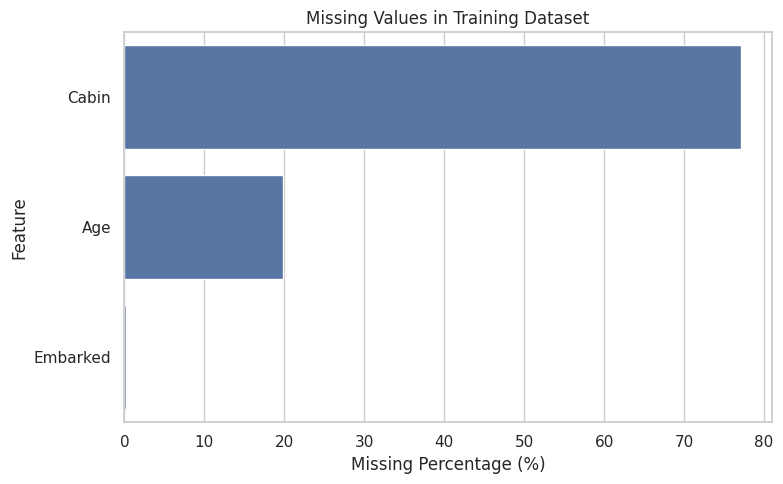

In [10]:
missing_train = (
    train_clean.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_train = missing_train[missing_train > 0]

plt.figure(figsize=(8, 5))

sns.barplot(
    x=missing_train.values,
    y=missing_train.index
)

plt.title("Missing Values in Training Dataset")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 6. Duplicate Record Audit

Duplicate records can artificially increase the representation of certain observations and potentially bias both analysis and machine learning models.

We will perform three checks:

1. Completely duplicated rows.
2. Duplicate `PassengerId` values.
3. Duplicate passenger names.

In [11]:
print("Exact Duplicate Rows")
print("-" * 30)

print(
    f"Training: {train_clean.duplicated().sum()}"
)

print(
    f"Test:     {test_clean.duplicated().sum()}"
)

Exact Duplicate Rows
------------------------------
Training: 0
Test:     0


In [12]:
print("PassengerId Uniqueness")
print("-" * 30)

print(
    f"Training PassengerIds: "
    f"{train_clean['PassengerId'].nunique()} unique "
    f"out of {len(train_clean)} rows"
)

print(
    f"Test PassengerIds: "
    f"{test_clean['PassengerId'].nunique()} unique "
    f"out of {len(test_clean)} rows"
)

PassengerId Uniqueness
------------------------------
Training PassengerIds: 891 unique out of 891 rows
Test PassengerIds: 418 unique out of 418 rows


In [13]:
duplicate_names = train_clean[
    train_clean["Name"].duplicated(keep=False)
].sort_values("Name")

print(
    f"Rows associated with duplicated names: "
    f"{len(duplicate_names)}"
)

display(
    duplicate_names[
        [
            "PassengerId",
            "Name",
            "Age",
            "Sex",
            "Ticket"
        ]
    ]
)

Rows associated with duplicated names: 0


,PassengerId,Name,Age,Sex,Ticket


## 7. Data Type Validation

We will verify that each feature is stored using a reasonable data type.

Some variables require conceptual interpretation in addition to their technical Pandas data type.


In [15]:
dtype_comparison = pd.DataFrame({
    "Train Type": train_clean.dtypes.astype(str),
    "Test Type": test_clean.dtypes.astype(str)
})

dtype_comparison

,Train Type,Test Type
Age,float64,float64
Cabin,object,object
Embarked,object,object
Fare,float64,float64
Name,object,object
Parch,int64,int64
PassengerId,int64,int64
Pclass,int64,int64
Sex,object,object
SibSp,int64,int64


## 8. Categorical Value Validation

Categorical features should contain only valid and expected categories.

We will inspect the unique values and frequency distributions of:

* `Sex`
* `Embarked`
* `Pclass`

In [16]:
categorical_columns = [
    "Sex",
    "Embarked",
    "Pclass"
]

for column in categorical_columns:
    print(f"\n{'=' * 50}")
    print(f"TRAIN - {column}")
    print(train_clean[column].value_counts(dropna=False))

    print(f"\nTEST - {column}")
    print(test_clean[column].value_counts(dropna=False))


TRAIN - Sex
Sex
male      577
female    314
Name: count, dtype: int64

TEST - Sex
Sex
male      266
female    152
Name: count, dtype: int64

TRAIN - Embarked
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

TEST - Embarked
Embarked
S    270
C    102
Q     46
Name: count, dtype: int64

TRAIN - Pclass
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

TEST - Pclass
Pclass
3    218
1    107
2     93
Name: count, dtype: int64


## 9. Empty String and Whitespace Audit

Missing information is not always represented as `NaN`.

Text columns may contain:

* Empty strings.
* Strings containing only spaces.
* Unnecessary leading or trailing whitespace.

In [17]:
object_columns = train_clean.select_dtypes(
    include="object"
).columns

for column in object_columns:
    empty_count = (
        train_clean[column]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    print(
        f"{column}: {empty_count} empty/blank values"
    )

Name: 0 empty/blank values
Sex: 0 empty/blank values
Ticket: 0 empty/blank values
Cabin: 687 empty/blank values
Embarked: 2 empty/blank values


## 10. Numerical Range Validation

Extreme values are not automatically data errors.

For example, a very high ticket fare may represent a legitimate first-class or group booking rather than incorrect data.

Before performing formal outlier analysis, we will first check numerical features for logically impossible or suspicious values.

We will inspect:

* `Age`
* `Fare`
* `SibSp`
* `Parch`
* `Pclass`

In [18]:
numerical_check_columns = [
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "Pclass"
]

train_clean[numerical_check_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000


In [19]:
print("Potential Invalid Value Checks")
print("-" * 40)

print(
    "Negative ages:",
    (train_clean["Age"] < 0).sum()
)

print(
    "Negative fares:",
    (train_clean["Fare"] < 0).sum()
)

print(
    "Negative SibSp values:",
    (train_clean["SibSp"] < 0).sum()
)

print(
    "Negative Parch values:",
    (train_clean["Parch"] < 0).sum()
)

print(
    "Invalid Pclass values:",
    (~train_clean["Pclass"].isin([1, 2, 3])).sum()
)

Potential Invalid Value Checks
----------------------------------------
Negative ages: 0
Negative fares: 0
Negative SibSp values: 0
Negative Parch values: 0
Invalid Pclass values: 0


In [20]:
print("Test Dataset - Potential Invalid Values")
print("-" * 45)

print(
    "Negative ages:",
    (test_clean["Age"] < 0).sum()
)

print(
    "Negative fares:",
    (test_clean["Fare"] < 0).sum()
)

print(
    "Negative SibSp values:",
    (test_clean["SibSp"] < 0).sum()
)

print(
    "Negative Parch values:",
    (test_clean["Parch"] < 0).sum()
)

print(
    "Invalid Pclass values:",
    (~test_clean["Pclass"].isin([1, 2, 3])).sum()
)

Test Dataset - Potential Invalid Values
---------------------------------------------
Negative ages: 0
Negative fares: 0
Negative SibSp values: 0
Negative Parch values: 0
Invalid Pclass values: 0


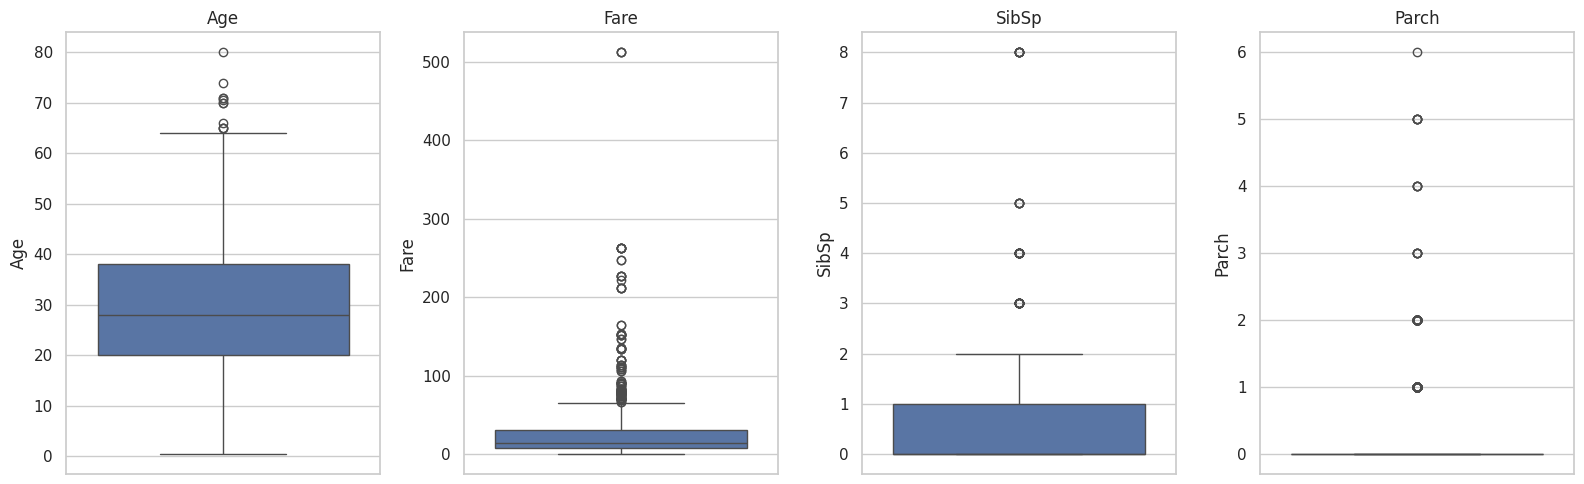

In [21]:
fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 5)
)

sns.boxplot(
    y=train_clean["Age"],
    ax=axes[0]
)
axes[0].set_title("Age")

sns.boxplot(
    y=train_clean["Fare"],
    ax=axes[1]
)
axes[1].set_title("Fare")

sns.boxplot(
    y=train_clean["SibSp"],
    ax=axes[2]
)
axes[2].set_title("SibSp")

sns.boxplot(
    y=train_clean["Parch"],
    ax=axes[3]
)
axes[3].set_title("Parch")

plt.tight_layout()
plt.show()

## 11. Investigating `Cabin` Missingness

`Cabin` has the largest proportion of missing values in the dataset.

Before deciding whether to drop the feature, we should investigate whether the availability of cabin information differs across other passenger characteristics.

Passenger class is particularly relevant because cabin assignments and record availability may differ between travel classes.

In [22]:
cabin_missing_by_class = (
    train_clean
    .assign(
        CabinKnown=train_clean["Cabin"].notna()
    )
    .groupby("Pclass")["CabinKnown"]
    .agg(["count", "mean"])
)

cabin_missing_by_class["Known Percentage"] = (
    cabin_missing_by_class["mean"] * 100
).round(2)

cabin_missing_by_class

,count,mean,Known Percentage
Pclass,,,
1,216,0.814815,81.48
2,184,0.086957,8.70
3,491,0.024440,2.44


## 12. Investigating `Age` Missingness

`Age` contains a substantial number of missing observations.

Rather than immediately replacing missing ages with the overall mean or median, we will examine whether age availability differs across broad passenger groups.

In [23]:
age_missing_by_class = (
    train_clean
    .assign(
        AgeKnown=train_clean["Age"].notna()
    )
    .groupby("Pclass")["AgeKnown"]
    .agg(["count", "mean"])
)

age_missing_by_class["Known Percentage"] = (
    age_missing_by_class["mean"] * 100
).round(2)

age_missing_by_class

,count,mean,Known Percentage
Pclass,,,
1,216,0.861111,86.11
2,184,0.940217,94.02
3,491,0.723014,72.30


In [24]:
age_missing_by_sex = (
    train_clean
    .assign(
        AgeKnown=train_clean["Age"].notna()
    )
    .groupby("Sex")["AgeKnown"]
    .agg(["count", "mean"])
)

age_missing_by_sex["Known Percentage"] = (
    age_missing_by_sex["mean"] * 100
).round(2)

age_missing_by_sex

,count,mean,Known Percentage
Sex,,,
female,314,0.831210,83.12
male,577,0.785095,78.51


## 13. Investigating Missing `Embarked` Values

Only a very small number of training observations have missing values for `Embarked`.

We will inspect these passengers and compare them with other passengers using features such as passenger class and fare.

Because only a small number of values are missing, several reasonable strategies may be possible, including:

* Imputation using the most frequent embarkation port.
* Group-based imputation using passenger characteristics.
* A more targeted inference based on similar passengers.

In [25]:
missing_embarked = train_clean[
    train_clean["Embarked"].isna()
]

display(
    missing_embarked[
        [
            "PassengerId",
            "Name",
            "Pclass",
            "Fare",
            "Ticket",
            "Cabin"
        ]
    ]
)

,PassengerId,Name,Pclass,Fare,Ticket,Cabin
61,62,"Icard, Miss. Amelie",1,80.0,113572,B28
829,830,"Stone, Mrs. George Nelson (Martha Evelyn)",1,80.0,113572,B28


In [26]:
embarked_comparison = (
    train_clean
    .groupby(
        ["Pclass", "Embarked"],
        dropna=True
    )["Fare"]
    .agg(
        Count="count",
        MedianFare="median",
        MeanFare="mean"
    )
    .round(2)
)

embarked_comparison

Count  MedianFare  MeanFare
Pclass Embarked                             
1      C            85       78.27    104.72
       Q             2       90.00     90.00
       S           127       52.00     70.36
2      C            17       24.00     25.36
       Q             3       12.35     12.35
       S           164       13.50     20.33
3      C            66        7.90     11.21
       Q            72        7.75     11.18
       S           353        8.05     14.64

## 14. Investigating Missing `Fare`

The test dataset contains a missing value in the `Fare` feature.

Because fare is strongly related to factors such as passenger class and potentially travel group, replacing the value with the overall dataset median may ignore useful contextual information.

In [34]:
missing_fare_rows = test_clean[
    test_clean["Fare"].isna()
]

print("Passengers with missing Fare:")
display(
    missing_fare_rows[
        [
            "PassengerId",
            "Pclass",
            "Sex",
            "Age",
            "SibSp",
            "Parch",
            "Ticket",
            "Embarked"
        ]
    ]
)

Passengers with missing Fare:


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Embarked
152,1044,3,male,60.5,0,0,3701,S


In [28]:
fare_group_summary = (
    train_clean
    .groupby(
        ["Pclass", "Embarked"]
    )["Fare"]
    .agg(
        Count="count",
        MedianFare="median",
        MeanFare="mean"
    )
    .round(2)
)

fare_group_summary

Count  MedianFare  MeanFare
Pclass Embarked                             
1      C            85       78.27    104.72
       Q             2       90.00     90.00
       S           127       52.00     70.36
2      C            17       24.00     25.36
       Q             3       12.35     12.35
       S           164       13.50     20.33
3      C            66        7.90     11.21
       Q            72        7.75     11.18
       S           353        8.05     14.64

## 15. Cleaning Strategy

After auditing the data, we can separate the identified issues into two categories.

### Issues That Can Be Safely Addressed During Cleaning

#### `Embarked`

Only a very small number of values are missing in the training dataset.

A simple and reproducible imputation strategy can be used after reviewing the available evidence. Because the number of affected observations is extremely small, this is unlikely to substantially distort the dataset.

#### `Fare`

Only one value is missing in the test dataset.

A group-based median using relevant passenger characteristics such as `Pclass` and `Embarked` provides a reasonable initial imputation strategy.

---

### Issues Deferred to Feature Engineering or Model Preprocessing

#### `Age`

Age will not be permanently imputed in this notebook.

Information extracted later from `Name`, particularly passenger titles, may provide a more meaningful basis for estimating missing ages.

Age imputation should also eventually be incorporated into a reproducible preprocessing pipeline where appropriate.

#### `Cabin`

The `Cabin` column will not be dropped.

Although it contains substantial missing data, the available values may provide useful information such as passenger deck. Missing cabin information itself may also be informative.

Cabin-related transformations will therefore be handled during feature engineering.

#### `Name`

The original name will be preserved for later extraction of features such as `Title` and potentially `Surname`.

#### `Ticket`

The original ticket value will be preserved because it may provide information about passenger groups, shared bookings, and ticket prefixes.


In [29]:
embarked_mode = train_clean["Embarked"].mode()[0]

print(
    f"Most frequent Embarked value: "
    f"{embarked_mode}"
)

train_clean["Embarked"] = (
    train_clean["Embarked"]
    .fillna(embarked_mode)
)

Most frequent Embarked value: S


In [35]:
missing_fare_row = missing_fare_rows.iloc[0]

fare_pclass = missing_fare_row["Pclass"]
fare_embarked = missing_fare_row["Embarked"]

print(f"Passenger Class: {fare_pclass}")
print(f"Embarked: {fare_embarked}")

# Calculate group median from training data
group_median_fare = train_clean.loc[
    (train_clean["Pclass"] == fare_pclass) &
    (train_clean["Embarked"] == fare_embarked),
    "Fare"
].median()

print(
    f"\nMedian Fare for Pclass={fare_pclass}, "
    f"Embarked={fare_embarked}: "
    f"{group_median_fare}"
)

Passenger Class: 3
Embarked: S

Median Fare for Pclass=3, Embarked=S: 8.05


In [36]:
if pd.isna(group_median_fare):
    group_median_fare = train_clean.loc[
        train_clean["Pclass"] == fare_pclass,
        "Fare"
    ].median()

    print(
        "Group median was unavailable. "
        "Using Pclass median instead."
    )

print(f"Fare value used for imputation: {group_median_fare:.2f}")

Fare value used for imputation: 8.05


In [37]:
# Impute the missing Fare
test_clean["Fare"] = test_clean["Fare"].fillna(
    group_median_fare
)

print(
    "Missing Fare values remaining:",
    test_clean["Fare"].isna().sum()
)

Missing Fare values remaining: 0


## 16. Post-Cleaning Validation

After applying the initial cleaning steps, we perform a final validation to ensure that:

* Dataset dimensions have not changed unexpectedly.
* No rows were accidentally removed.
* `PassengerId` remains unique.
* The target variable remains unchanged.
* The resolved missing values are no longer present.
* Missing values intentionally deferred to later stages remain untouched.

In [38]:
print("Dataset Shapes")
print("-" * 30)

print(
    f"Original train: {train.shape}"
)

print(
    f"Clean train:    {train_clean.shape}"
)

print(
    f"Original test:  {test.shape}"
)

print(
    f"Clean test:     {test_clean.shape}"
)

Dataset Shapes
------------------------------
Original train: (891, 12)
Clean train:    (891, 12)
Original test:  (418, 11)
Clean test:     (418, 11)


In [39]:
assert train_clean.shape == train.shape
assert test_clean.shape == test.shape

assert train_clean["PassengerId"].is_unique
assert test_clean["PassengerId"].is_unique

assert train_clean["Survived"].equals(
    train["Survived"]
)

assert train_clean["Embarked"].isna().sum() == 0
assert test_clean["Fare"].isna().sum() == 0

print("All critical validation checks passed.")

All critical validation checks passed.


In [40]:
print("Remaining Missing Values - Training")
display(
    missing_summary(train_clean)
)

print("\nRemaining Missing Values - Test")
display(
    missing_summary(test_clean)
)

Remaining Missing Values - Training


,Data Type,Missing Count,Missing Percentage
Cabin,object,687,77.10
Age,float64,177,19.87



Remaining Missing Values - Test


,Data Type,Missing Count,Missing Percentage
Cabin,object,327,78.23
Age,float64,86,20.57


## 17. Save the Initial Cleaned Datasets

The initial cleaned datasets will be saved inside the `data/processed/` directory.

These files represent a minimally cleaned version of the original data.

At this stage:

* Straightforward missing-value issues have been resolved.
* Potentially informative raw features have been preserved.
* `Age` and `Cabin` still contain missing values intentionally.
* No feature engineering has been performed.

In [42]:
from pathlib import Path

processed_dir = Path(
    "/mnt/d/Acelin/Work/Code/titanic-kaggle/data/processed"
)

processed_dir.mkdir(
    parents=True,
    exist_ok=True
)

train_clean.to_csv(
    processed_dir / "train_clean.csv",
    index=False
)

test_clean.to_csv(
    processed_dir / "test_clean.csv",
    index=False
)

print("Cleaned datasets saved successfully.")

Cleaned datasets saved successfully.


In [43]:
train_check = pd.read_csv(
    "../data/processed/train_clean.csv"
)

test_check = pd.read_csv(
    "../data/processed/test_clean.csv"
)

print(
    "Reloaded training shape:",
    train_check.shape
)

print(
    "Reloaded test shape:",
    test_check.shape
)

assert train_check.shape == train_clean.shape
assert test_check.shape == test_clean.shape

print(
    "Saved files successfully validated."
)

Reloaded training shape: (891, 12)
Reloaded test shape: (418, 11)
Saved files successfully validated.


## 19. Phase 2 Summary

In this notebook, we completed a systematic data-quality audit of the Titanic training and test datasets.

### What We Completed

* Reloaded the original raw datasets.
* Created separate working copies for cleaning.
* Verified train-test structural consistency.
* Quantified missing values.
* Visualized missing-data severity.
* Checked for exact duplicate records.
* Verified passenger identifier uniqueness.
* Investigated duplicate passenger names without automatically removing them.
* Validated data types.
* Inspected categorical values for inconsistencies.
* Checked text columns for empty or whitespace-only values.
* Validated numerical features for logically impossible values.
* Investigated extreme numerical observations without automatically treating them as errors.
* Examined patterns associated with missing `Cabin` and `Age` information.
* Investigated the small number of missing `Embarked` and `Fare` values.
* Applied only minimal, conservative cleaning.
* Performed post-cleaning validation using explicit assertions.
* Saved and reloaded the cleaned datasets to verify file integrity.